# Why do the training and evaluation periods overlap — and why is that valid?

Short answer: the overlap is in **calendar ranges**, not in **rows**. The split is a
**purged, embargoed cross-validation**, not one train/test cut — so the timeline is
reused fold by fold (like ordinary k-fold), yet *no single model is ever trained and
tested on the same observation*. The pictures below are drawn from the **real**
splitter in `model/validation.py`, not a toy.

We'll build it up in four graphs:
1. **The fold map** — what each model actually trains and tests on.
2. **Union vs one model** — why the *ranges* overlap but a *single model* is clean.
3. **The purge+embargo zoom** — the gap that blocks the only real leak.
4. **Purged k-fold vs expanding walk-forward** — the honest caveat.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
warnings.filterwarnings("ignore")

ROOT = Path.cwd(); sys.path.insert(0, str(ROOT))
import config
from features import alpha
from model import validation        # the SAME splitter the pipeline uses
from IPython.display import display
config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Real trading calendar + real folds.
dates = alpha.load_features()["date"]
date_arr = dates.to_numpy()
udays = np.sort(dates.unique())
n_days = len(udays)
folds = list(validation.purged_walk_forward(dates))
n_folds = len(folds)
H, E = config.LABEL_HORIZON, config.EMBARGO_DAYS

# Colors used throughout.
HALO, TRAIN, TEST = "#e9e9e9", "#4c78a8", "#f58518"
cmap3 = ListedColormap([HALO, TRAIN, TEST])

def date_ticks(ax):
    xt = np.linspace(0, n_days - 1, 9).astype(int)
    ax.set_xticks(xt)
    ax.set_xticklabels([pd.Timestamp(udays[i]).strftime("%Y-%m") for i in xt])

print(f"{n_days} trading days  {pd.Timestamp(udays[0]).date()} → {pd.Timestamp(udays[-1]).date()}"
      f"  |  {n_folds} folds  |  label horizon {H}d, embargo {E}d")

2579 trading days  2015-01-09 → 2026-05-22  |  8 folds  |  label horizon 10d, embargo 5d


## 1 · The fold map — what each model trains and tests on

Each **row is one model** (one walk-forward fold). Orange = the dates it is *tested*
on (out-of-sample); blue = the dates it is *trained* on; grey = dropped by the
purge+embargo halo. Read down the rows: the orange test block marches forward in
time, and every other date is reused for training in the *other* folds.

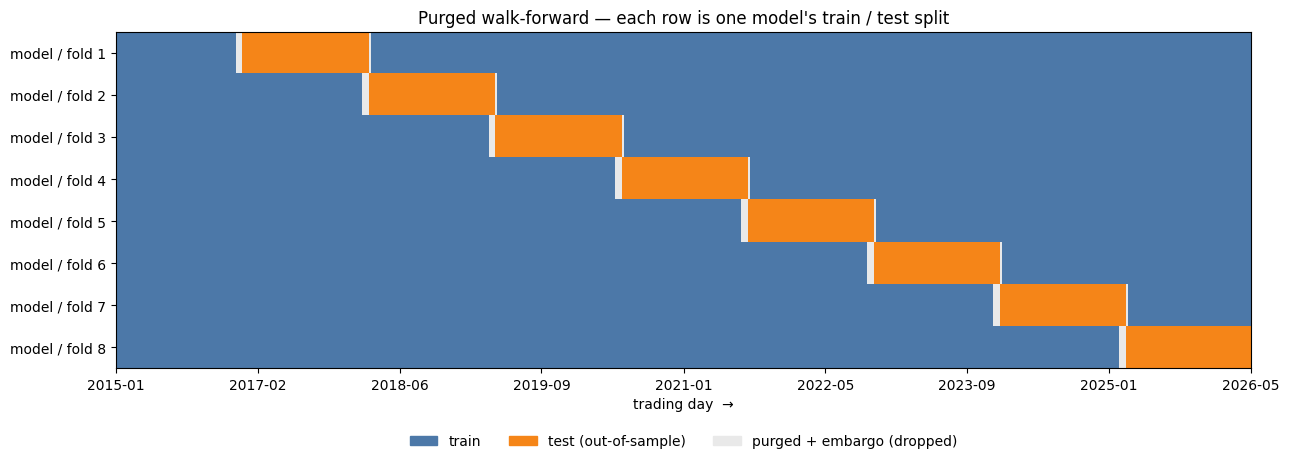

In [2]:
# Build a [fold x day] matrix: 0 = halo (dropped), 1 = train, 2 = test.
M = np.zeros((n_folds, n_days), dtype=int)
test_start_pos = []
for f, (tr, te) in enumerate(folds):
    tr_pos = np.searchsorted(udays, np.unique(date_arr[tr]))
    te_pos = np.searchsorted(udays, np.unique(date_arr[te]))
    M[f, tr_pos] = 1
    M[f, te_pos] = 2
    test_start_pos.append(te_pos[0])

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.imshow(M, aspect="auto", cmap=cmap3, vmin=0, vmax=2, interpolation="nearest")
ax.set_yticks(range(n_folds)); ax.set_yticklabels([f"model / fold {i+1}" for i in range(n_folds)])
ax.set_xlabel("trading day  →"); date_ticks(ax)
ax.set_title("Purged walk-forward — each row is one model's train / test split")
ax.legend(handles=[Patch(color=TRAIN, label="train"),
                   Patch(color=TEST, label="test (out-of-sample)"),
                   Patch(color=HALO, label="purged + embargo (dropped)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
fig.tight_layout(); fig.savefig(config.REPORTS_DIR / "cv_fold_map.png", dpi=130, bbox_inches="tight")
plt.show()

**What to notice:** within any single row, the blue (train) and orange (test) never
touch — there is a grey gap between them. That gap is the purge+embargo. So *per
model*, train and test are disjoint. The reason all the calendar gets reused is that
a date that is **test** in one row is **train** in the others.

## 2 · Why the *ranges* overlap but a single model doesn't

"Training set: 2015–2024" and "Evaluation set: 2016–2024" are the **unions across all
folds**, so of course their date ranges overlap. But that union is not any one model.
Top two bars = the unions (they cover almost the whole axis). Bottom bar = a single
model (fold 4): clean blue → grey gap → orange, with **no blue underneath the
orange**.

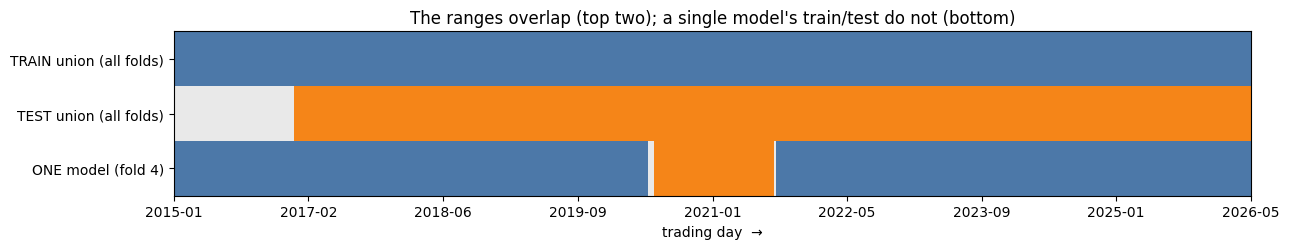

In [3]:
example = 3  # fold 4 (0-indexed)
strip = np.zeros((3, n_days), dtype=int)
strip[0, (M == 1).any(axis=0)] = 1          # any day used for TRAIN in some fold
strip[1, (M == 2).any(axis=0)] = 2          # any day used for TEST in some fold
strip[2] = M[example]                        # one specific model

fig, ax = plt.subplots(figsize=(13, 2.6))
ax.imshow(strip, aspect="auto", cmap=cmap3, vmin=0, vmax=2, interpolation="nearest")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["TRAIN union (all folds)", "TEST union (all folds)", f"ONE model (fold {example+1})"])
ax.set_xlabel("trading day  →"); date_ticks(ax)
ax.set_title("The ranges overlap (top two); a single model's train/test do not (bottom)")
fig.tight_layout(); fig.savefig(config.REPORTS_DIR / "cv_overlap_strip.png", dpi=130, bbox_inches="tight")
plt.show()

This is exactly the logic of ordinary k-fold cross-validation: every row of data is
used for training in most folds and for testing in exactly one. Aggregating the
**test** rows from all folds gives one big out-of-sample set spanning 2016–2024 — and
every prediction in it came from a model that did **not** train on that row.

## 3 · The purge + embargo zoom — the one real leak, blocked

Why a gap at all? The label is a **10-day forward return**, so a training row dated
`t` secretly contains information out to `t + 10`. If we trained on rows right up to
the test block, their labels would already "know" the start of the test period.

Below: each horizontal bar is one candidate training day's **label window** (`t →
t+10`). The vertical line is where the test fold begins. Bars are **kept** (green)
only if they end safely before the line; bars whose window crosses the line leak
(red, *purged*), and a few extra days are dropped as a safety buffer (amber,
*embargo*). Rule in code: keep a training day only if its position `< test_start −
(horizon + embargo)`.

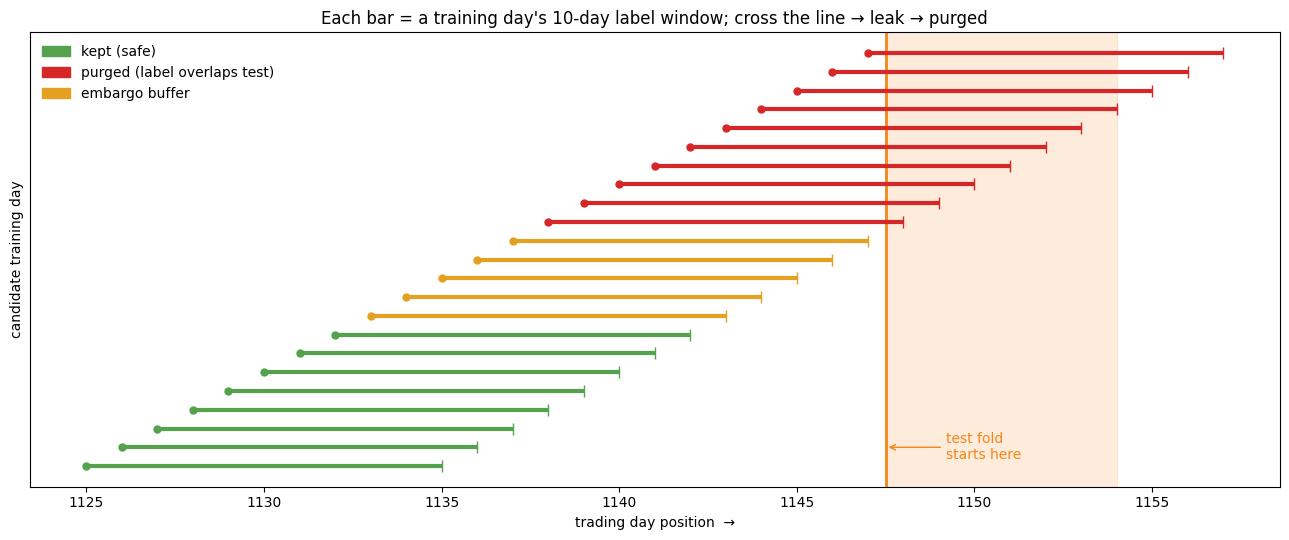

In [4]:
KEPT, PURGE, EMB = "#54a24b", "#d62728", "#e4a020"
ts = test_start_pos[example]                 # test-start position for fold 4
cutoff = ts - (H + E)                          # code's keep boundary
first = ts - (H + E + 8)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axvspan(ts - 0.5, ts + 6, color=TEST, alpha=0.15)         # test region
ax.axvline(ts - 0.5, color=TEST, lw=2)
for p in range(first, ts):
    if p < cutoff:
        c, label = KEPT, "kept (train)"
    elif (p + H) >= ts:
        c, label = PURGE, "purged: label window overlaps test"
    else:
        c, label = EMB, "embargo buffer"
    ax.hlines(p, p, p + H, color=c, lw=3)
    ax.plot(p, p, "o", color=c, ms=5)
    ax.plot(p + H, p, "|", color=c, ms=9)

ax.annotate("test fold\nstarts here", xy=(ts - 0.5, first + 1),
            xytext=(ts + 1.2, first + 1), color=TEST, fontsize=10, va="center",
            arrowprops=dict(arrowstyle="->", color=TEST))
ax.set_xlabel("trading day position  →"); ax.set_ylabel("candidate training day")
ax.set_yticks([]); ax.set_title("Each bar = a training day's 10-day label window; cross the line → leak → purged")
ax.legend(handles=[Patch(color=KEPT, label="kept (safe)"),
                   Patch(color=PURGE, label="purged (label overlaps test)"),
                   Patch(color=EMB, label="embargo buffer")],
          loc="upper left", frameon=False)
fig.tight_layout(); fig.savefig(config.REPORTS_DIR / "cv_purge_zoom.png", dpi=130, bbox_inches="tight")
plt.show()

Because every red/amber row is removed, the model that predicts the test fold has
**never seen any data whose label leaks into that fold**. That is the precise
condition that makes reusing the calendar valid: overlap in *time* is fine; overlap
in *information* is not, and the purge removes it.

## 4 · The honest caveat — purged k-fold vs expanding walk-forward

Look again at fold 1 in graph 1: its **train** (blue) sits on *both* sides of the
test block — including dates **after** it. So early folds are partly trained on the
future. That is fine for asking *"does this signal generalize to held-out
observations?"* (the IC question), because the only mechanical leak — overlapping
labels — is purged.

It is **not** a live-trading simulation, where at each point you only have the past.
The left panel is what this repo uses (purged k-fold); the right panel is the
stricter **expanding walk-forward** (train on the past only). Notice the right
panel's early folds have very little blue and the future stays grey.

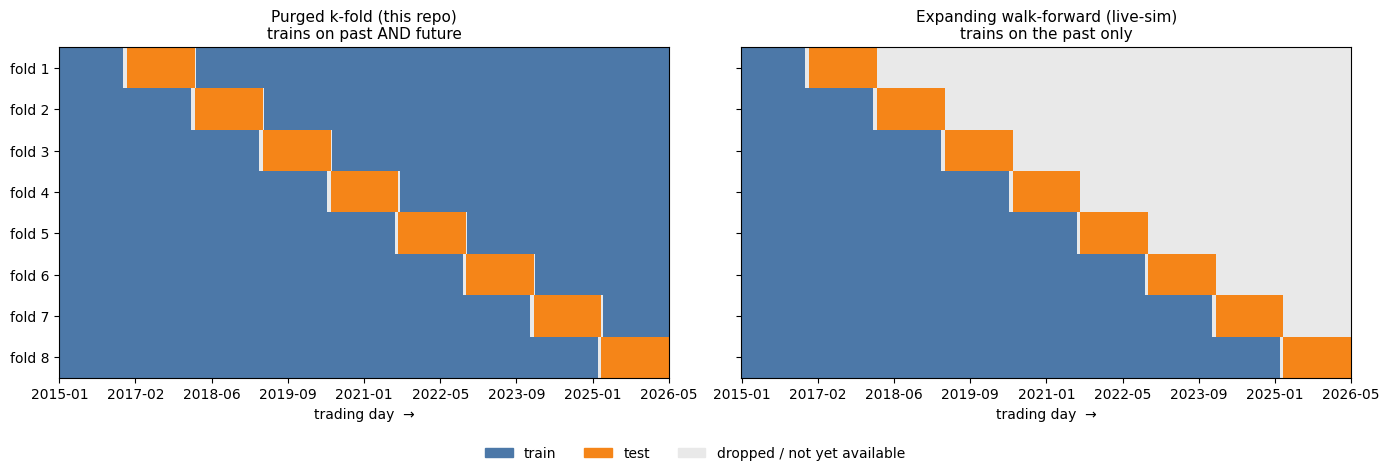

In [5]:
# Expanding-window view: keep only training days BEFORE each test block.
M_exp = np.zeros_like(M)
for f, (tr, te) in enumerate(folds):
    ts_f = test_start_pos[f]
    tr_pos = np.searchsorted(udays, np.unique(date_arr[tr]))
    M_exp[f, tr_pos[tr_pos < ts_f]] = 1
    M_exp[f, np.searchsorted(udays, np.unique(date_arr[te]))] = 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, mat, ttl in [(axes[0], M, "Purged k-fold (this repo)\ntrains on past AND future"),
                     (axes[1], M_exp, "Expanding walk-forward (live-sim)\ntrains on the past only")]:
    ax.imshow(mat, aspect="auto", cmap=cmap3, vmin=0, vmax=2, interpolation="nearest")
    ax.set_yticks(range(n_folds)); ax.set_yticklabels([f"fold {i+1}" for i in range(n_folds)])
    ax.set_xlabel("trading day  →"); date_ticks(ax); ax.set_title(ttl, fontsize=11)
fig.legend(handles=[Patch(color=TRAIN, label="train"), Patch(color=TEST, label="test"),
                    Patch(color=HALO, label="dropped / not yet available")],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(config.REPORTS_DIR / "cv_twosided_vs_expanding.png", dpi=130, bbox_inches="tight")
plt.show()

### Takeaway

- The overlapping date *ranges* are an artifact of **reusing the calendar across
  folds** — standard cross-validation. Any one model's train and test rows are
  disjoint, separated by a purge+embargo gap.
- That gap removes the **only** real leak here: overlapping 10-day labels. So the
  out-of-sample IC / Sharpe are honest measures of *signal generalization*.
- **Caveat:** this splitter is two-sided (uses future data for early folds), so it
  is purged **cross-validation**, not a point-in-time **walk-forward**. For a
  deployment-realistic number, switch to the expanding-window view (right panel) and
  expect somewhat lower, more conservative results — especially in the early years.